# Análise de sentimento por clube e portal

Este notebook:

1. Lê todos os CSV da pasta `noticias`.
2. Concatena em um único DataFrame e harmoniza colunas.
3. Mantém **uma linha por título**, escolhendo a **`data_rodagem` mais antiga** quando o mesmo título aparece em vários arquivos.
4. Aplica **análise de sentimento** no título com o modelo Hugging Face **`cardiffnlp/twitter-xlm-roberta-base-sentiment`** (XLM-RoBERTa treinado em tweets, **multilíngue**; útil em português, mas com limitações em manchetes de esporte).
5. Resume e compara **sentimento por clube × portal** (médias, proporções, séries no tempo e teste não paramétrico quando houver amostras suficientes).

**Dependências:** na raiz do projeto, `pip install -r requirements_notebook.txt` (idealmente no mesmo venv ou em um venv só para análise). A primeira execução baixa o modelo do Hugging Face.


In [11]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

try:
    from IPython.display import display
except ImportError:
    display = print  # execução fora do kernel Jupyter

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12


In [12]:
# Raiz do projeto = pasta pai de "noticias"
PROJETO = Path.cwd()
if not (PROJETO / "noticias").is_dir():
    PROJETO = PROJETO.parent
PASTA_NOTICIAS = PROJETO / "noticias"
assert PASTA_NOTICIAS.is_dir(), f"Pasta não encontrada: {PASTA_NOTICIAS}"

arquivos = sorted(PASTA_NOTICIAS.glob("*.csv"))
print(f"{len(arquivos)} arquivos CSV em {PASTA_NOTICIAS}")
for p in arquivos[:5]:
    print("  ", p.name)
if len(arquivos) > 5:
    print("  ...")

38 arquivos CSV em /Users/jonas/Desktop/Projeto Futebol/noticias
   noticias_ge_2026-01-31.csv
   noticias_ge_2026-02-01.csv
   noticias_todos_portais_2026-01-31.csv
   noticias_todos_portais_2026-02-01.csv
   noticias_todos_portais_2026-02-02.csv
  ...


In [13]:
COLUNAS_ESPERADAS = ["titulo", "link", "clube", "portal", "data_rodagem", "data_publicacao"]

partes = []
for path in arquivos:
    try:
        df_arq = pd.read_csv(path, encoding="utf-8")
    except UnicodeDecodeError:
        df_arq = pd.read_csv(path, encoding="latin-1")
    df_arq["_arquivo_origem"] = path.name
    faltando = set(COLUNAS_ESPERADAS) - set(df_arq.columns)
    if faltando:
        print(f"Ignorando {path.name}: faltam colunas {faltando}")
        continue
    partes.append(df_arq[COLUNAS_ESPERADAS + ["_arquivo_origem"]])

df = pd.concat(partes, ignore_index=True)
print("Linhas concatenadas:", len(df))
df.head()

Linhas concatenadas: 4686


,titulo,link,clube,portal,data_rodagem,data_publicacao,_arquivo_origem
0,palmeiras,http://globoesporte.globo.com/futebol/times/pa...,Palmeiras,globoesporte,2026-01-31,NaN,noticias_ge_2026-01-31.csv
1,últimas,https://ge.globo.com/futebol/times/palmeiras/,Palmeiras,globoesporte,2026-01-31,NaN,noticias_ge_2026-01-31.csv
2,jogos do palmeiras,https://ge.globo.com/futebol/times/palmeiras/a...,Palmeiras,globoesporte,2026-01-31,NaN,noticias_ge_2026-01-31.csv
3,vídeos,https://ge.globo.com/futebol/times/palmeiras/v...,Palmeiras,globoesporte,2026-01-31,NaN,noticias_ge_2026-01-31.csv
4,"Tudo sobre o Palmeiras na Globo, sportv, ge e ...",https://ge.globo.com/futebol/times/palmeiras/p...,Palmeiras,globoesporte,2026-01-31,NaN,noticias_ge_2026-01-31.csv


In [14]:
def normalizar_titulo_chave(s: str) -> str:
    s = str(s).strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s


def harmonizar_portal(p: str) -> str:
    p = str(p).strip().lower()
    if p == "globoesporte":
        return "ge"
    return p


df["titulo"] = df["titulo"].astype(str)
df["titulo_chave"] = df["titulo"].map(normalizar_titulo_chave)
df["portal"] = df["portal"].map(harmonizar_portal)
df["data_rodagem"] = pd.to_datetime(df["data_rodagem"], errors="coerce")

# Opcional: reduzir ruído de menu / links genéricos (comentar se quiser tudo)
RUÍDO = {
    "últimas",
    "ultimas",
    "vídeos",
    "videos",
    "palmeiras",
    "corinthians",
    "são paulo",
    "sao paulo",
    "santos",
    "flamengo",
    "vasco",
    "mostrar mais",
    "veja mais",
}
mask_ruido = df["titulo_chave"].isin(RUÍDO) | (df["titulo"].str.len() < 12)
print("Linhas removidas como ruído de navegação / título curto:", int(mask_ruido.sum()))
df = df.loc[~mask_ruido].copy()

df = df.sort_values("data_rodagem", ascending=True)
df_dedup = df.drop_duplicates(subset=["titulo_chave"], keep="first").copy()
df_dedup = df_dedup.drop(columns=["titulo_chave"])

print("Após deduplicação (1 por título, data_rodagem mais antiga):", len(df_dedup))
df_dedup[["titulo", "clube", "portal", "data_rodagem", "_arquivo_origem"]].head(10)

Linhas removidas como ruído de navegação / título curto: 1555
Após deduplicação (1 por título, data_rodagem mais antiga): 1481


,titulo,clube,portal,data_rodagem,_arquivo_origem
2,jogos do palmeiras,Palmeiras,ge,2026-01-31,noticias_ge_2026-01-31.csv
191,Treino do São Paulo: Alisson volta e é recebid...,São Paulo,ge,2026-01-31,noticias_todos_portais_2026-01-31.csv
192,Entenda os inquéritos que apuram irregularidad...,São Paulo,ge,2026-01-31,noticias_todos_portais_2026-01-31.csv
196,jogos do santos,Santos,ge,2026-01-31,noticias_todos_portais_2026-01-31.csv
198,"Tudo sobre o Santos na Globo, sportv e ge",Santos,ge,2026-01-31,noticias_todos_portais_2026-01-31.csv
199,"Um ano da volta de Neymar: gols decisivos, les...",Santos,ge,2026-01-31,noticias_todos_portais_2026-01-31.csv
200,Santos libera Billal Brahimi para procurar nov...,Santos,ge,2026-01-31,noticias_todos_portais_2026-01-31.csv
201,"Rony é anunciado pelo Santos: ""Fazer história ...",Santos,ge,2026-01-31,noticias_todos_portais_2026-01-31.csv
202,Escalação: Rony fica à disposição; Neymar faz ...,Santos,ge,2026-01-31,noticias_todos_portais_2026-01-31.csv
203,Billal em baixa: Santos libera Brahimi para pr...,Santos,ge,2026-01-31,noticias_todos_portais_2026-01-31.csv


portal,ge,lance,uol
clube,,,
Corinthians,207,6,76
Flamengo,162,23,94
Palmeiras,154,8,89
Santos,163,8,90
São Paulo,97,2,100
Vasco,134,13,55


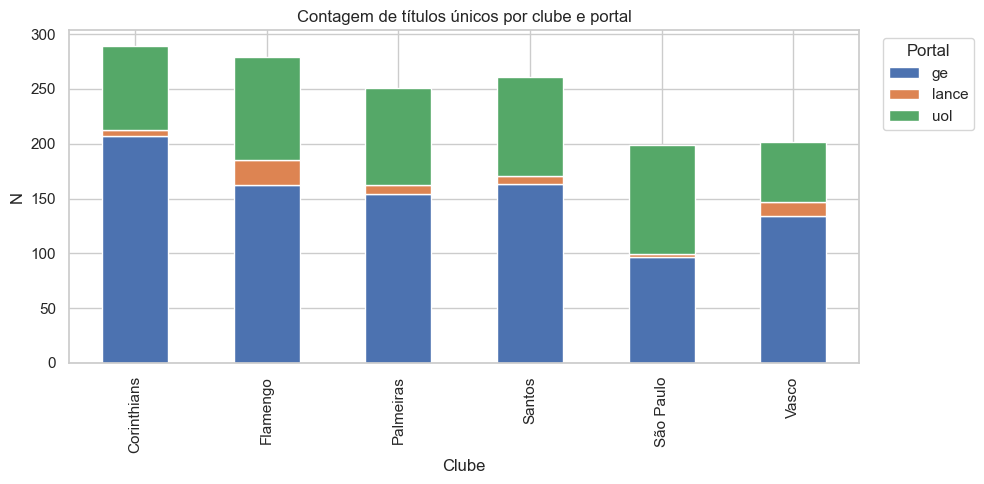

In [15]:
contagem = df_dedup.groupby(["clube", "portal"]).size().unstack(fill_value=0)
display(contagem)
contagem.plot(kind="bar", stacked=True, figsize=(10, 5), title="Contagem de títulos únicos por clube e portal")
plt.ylabel("N")
plt.xlabel("Clube")
plt.legend(title="Portal", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [16]:
from transformers import pipeline
import pandas as pd

MODELO = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

clf = pipeline(
    task="sentiment-analysis",
    model=MODELO,
    tokenizer=MODELO,
    truncation=True,
)

# O pipeline exige list[str]; células vazias/NaN no CSV viram float e quebram o batch
titulos = df_dedup["titulo"].apply(lambda x: "" if pd.isna(x) else str(x)).tolist()

batch = 16
resultados = []
for i in range(0, len(titulos), batch):
    chunk = titulos[i : i + batch]
    if not chunk:
        continue
    resultados.extend(clf(chunk))

df_dedup = df_dedup.reset_index(drop=True)
df_dedup["sent_label"] = [r["label"] for r in resultados]
df_dedup["sent_confidence"] = [float(r["score"]) for r in resultados]

label_map = {"negative": -1, "neutral": 0, "positive": 1}
df_dedup["sent_polaridade"] = df_dedup["sent_label"].map(label_map).fillna(0)
df_dedup["sent_indice"] = df_dedup["sent_polaridade"] * df_dedup["sent_confidence"]

df_dedup[["titulo", "clube", "portal", "sent_label", "sent_confidence", "sent_indice"]].head(12)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,titulo,clube,portal,sent_label,sent_confidence,sent_indice
0,jogos do palmeiras,Palmeiras,ge,neutral,0.754847,0.000000
1,Treino do São Paulo: Alisson volta e é recebid...,São Paulo,ge,neutral,0.597402,0.000000
2,Entenda os inquéritos que apuram irregularidad...,São Paulo,ge,neutral,0.576534,0.000000
3,jogos do santos,Santos,ge,neutral,0.704541,0.000000
4,"Tudo sobre o Santos na Globo, sportv e ge",Santos,ge,neutral,0.915291,0.000000
5,"Um ano da volta de Neymar: gols decisivos, les...",Santos,ge,neutral,0.601678,0.000000
6,Santos libera Billal Brahimi para procurar nov...,Santos,ge,neutral,0.680745,0.000000
7,"Rony é anunciado pelo Santos: ""Fazer história ...",Santos,ge,positive,0.684208,0.684208
8,Escalação: Rony fica à disposição; Neymar faz ...,Santos,ge,neutral,0.598332,0.000000
9,Billal em baixa: Santos libera Brahimi para pr...,Santos,ge,neutral,0.630412,0.000000


,clube,portal,n,media,mediana
0,Corinthians,ge,207,-0.114839,0.000000
1,Corinthians,lance,6,0.000000,0.000000
2,Corinthians,uol,76,-0.048237,0.000000
3,Flamengo,ge,162,-0.070663,0.000000
4,Flamengo,lance,23,-0.057310,0.000000
5,Flamengo,uol,94,-0.079171,0.000000
6,Palmeiras,ge,154,-0.014646,0.000000
7,Palmeiras,lance,8,-0.337001,-0.173650
8,Palmeiras,uol,89,-0.003763,0.000000
9,Santos,ge,163,-0.112557,0.000000


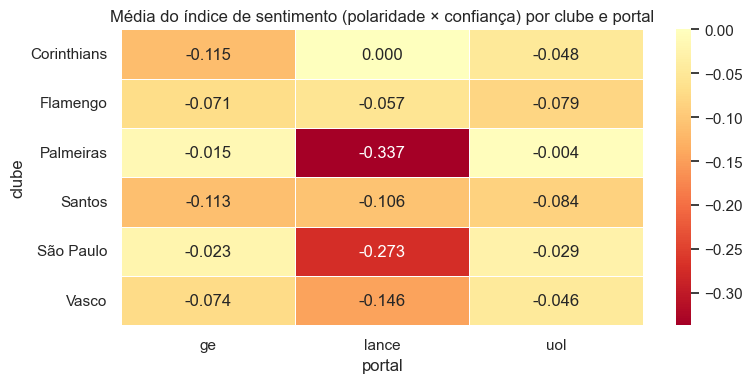

In [17]:
if "sent_indice" not in df_dedup.columns:
    raise RuntimeError("Execute antes a célula do modelo (sentimento); falta a coluna `sent_indice`.")

agg_mean = (
    df_dedup.groupby(["clube", "portal"], dropna=True)["sent_indice"]
    .agg(n="count", media="mean", mediana="median")
    .reset_index()
)
# pivot_table agrega duplicatas; pivot() quebra com ValueError se houver (clube, portal) repetido
pivot_media = df_dedup.pivot_table(
    index="clube",
    columns="portal",
    values="sent_indice",
    aggfunc="mean",
    dropna=False,
)
display(agg_mean.sort_values(["clube", "portal"]))

if pivot_media.size == 0:
    print("Sem dados para o heatmap (matriz vazia após agregação).")
else:
    plt.figure(figsize=(8, max(4, 0.4 * len(pivot_media))))
    sns.heatmap(
        pivot_media,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn",
        center=0,
        linewidths=0.5,
        mask=pivot_media.isna(),
    )
    plt.title("Média do índice de sentimento (polaridade × confiança) por clube e portal")
    plt.tight_layout()
    plt.show()


### Modelo de sentimento

- **Nome no Hugging Face:** `cardiffnlp/twitter-xlm-roberta-base-sentiment`
- **Tipo:** classificação de sentimento em **3 classes** (negativo / neutro / positivo), com um **score de confiança** para o rótulo escolhido.
- **Contexto de treino:** texto curto de redes sociais (Twitter/X), **multilíngue** — não é um modelo só para português nem para manchetes de jornal.

### O que é «polaridade × confiança» (`sent_indice`)?

- O modelo devolve um **rótulo** (`negative`, `neutral`, `positive`) e uma **probabilidade** entre 0 e 1 (`sent_confidence`).
- **Polaridade** numérica: negativo = −1, neutro = 0, positivo = +1 (`sent_polaridade`).
- **`sent_indice` = polaridade × confiança**: fica entre **−1 e +1**. Valores mais extremos combinam **direção** do rótulo com **quão “seguro”** o modelo diz estar.

### Faz sentido usar só polaridade (sem confiança)?

- **Sim, em muitos casos:** a média de `sent_polaridade` trata neg/neu/pos de forma **uniforme** (cada título pesa igual). Isso evita que um único título com rótulo “forte” mas probabilidade baixa puxe a média de um jeito estranho.
- **O que se perde:** deixamos de ver se o modelo está **indeciso** (confiança baixa). Para isso, `sent_indice` ou as **proporções** por rótulo continuam úteis.

Abaixo há **duas faixas de gráficos de barras por portal:** primeiro com **média de `sent_indice`**, depois com **média só de `sent_polaridade`**. Em seguida, **uma série temporal por portal** (média diária por clube, suavizada com **média móvel de 7 dias** sobre a média diária de polaridade).


In [ ]:
if "sent_indice" not in df_dedup.columns:
    raise RuntimeError("Execute antes a célula do modelo (sentimento).")

PORTAIS = ["ge", "uol", "lance"]
NOMES = {"ge": "GE (Globo)", "uol": "UOL", "lance": "Lance"}

# --- A) Média polaridade × confiança por clube
for portal in PORTAIS:
    sub = df_dedup[df_dedup["portal"] == portal]
    if sub.empty:
        print(f"Sem dados para o portal «{portal}» (barras índice).")
        continue
    agg = (
        sub.groupby("clube", observed=True)["sent_indice"]
        .mean()
        .rename("valor")
        .reset_index()
        .sort_values("clube")
    )
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(agg))
    cores = plt.cm.RdYlGn(0.5 + 0.5 * np.clip(agg["valor"], -1, 1))
    ax.bar(x, agg["valor"], color=cores, edgecolor="0.35", linewidth=0.4)
    ax.set_xticks(x, agg["clube"], rotation=30, ha="right")
    ax.axhline(0, color="0.4", lw=1)
    ax.set_ylabel("Média de sent_indice (polaridade × confiança)")
    ax.set_xlabel("Clube")
    ax.set_title(f"Média por clube — {NOMES.get(portal, portal)} — índice com confiança")
    ax.set_ylim(-1.05, 1.05)
    plt.tight_layout()
    plt.show()

# --- B) Média só polaridade (−1 / 0 / +1) por clube
for portal in PORTAIS:
    sub = df_dedup[df_dedup["portal"] == portal]
    if sub.empty:
        print(f"Sem dados para o portal «{portal}» (barras polaridade).")
        continue
    agg = (
        sub.groupby("clube", observed=True)["sent_polaridade"]
        .mean()
        .rename("valor")
        .reset_index()
        .sort_values("clube")
    )
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(agg))
    cores = plt.cm.RdYlGn(0.5 + 0.5 * np.clip(agg["valor"], -1, 1))
    ax.bar(x, agg["valor"], color=cores, edgecolor="0.35", linewidth=0.4)
    ax.set_xticks(x, agg["clube"], rotation=30, ha="right")
    ax.axhline(0, color="0.4", lw=1)
    ax.set_ylabel("Média de sent_polaridade (sem confiança)")
    ax.set_xlabel("Clube")
    ax.set_title(f"Média por clube — {NOMES.get(portal, portal)} — só polaridade")
    ax.set_ylim(-1.05, 1.05)
    plt.tight_layout()
    plt.show()

# --- C) Sentimento ao longo do tempo (um gráfico por portal)
# Média diária por clube da polaridade; suavização: média móvel de 7 dias por clube
for portal in PORTAIS:
    sub = df_dedup[df_dedup["portal"] == portal].copy()
    if sub.empty:
        print(f"Sem dados para o portal «{portal}» (série temporal).")
        continue
    sub["data"] = pd.to_datetime(sub["data_rodagem"], errors="coerce").dt.normalize()
    sub = sub.dropna(subset=["data"])
    if sub.empty:
        print(f"Datas inválidas para «{portal}».")
        continue
    daily = (
        sub.groupby(["data", "clube"], observed=True)["sent_polaridade"]
        .mean()
        .reset_index()
        .sort_values(["clube", "data"])
    )
    daily["suave_7d"] = daily.groupby("clube", observed=True)["sent_polaridade"].transform(
        lambda s: s.rolling(7, min_periods=1).mean()
    )
    fig, ax = plt.subplots(figsize=(11, 5))
    for clube, g in daily.groupby("clube", observed=True):
        ax.plot(g["data"], g["suave_7d"], marker="o", ms=2.5, lw=1.3, label=clube)
    ax.axhline(0, color="0.45", lw=1, ls="--")
    ax.set_ylim(-1.05, 1.05)
    ax.set_xlabel("Data (data_rodagem)")
    ax.set_ylabel("Polaridade média (7d) — −1 neg, 0 neu, +1 pos")
    ax.set_title(
        f"Série temporal — {NOMES.get(portal, portal)} — média móvel 7 dias da média diária de polaridade"
    )
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()


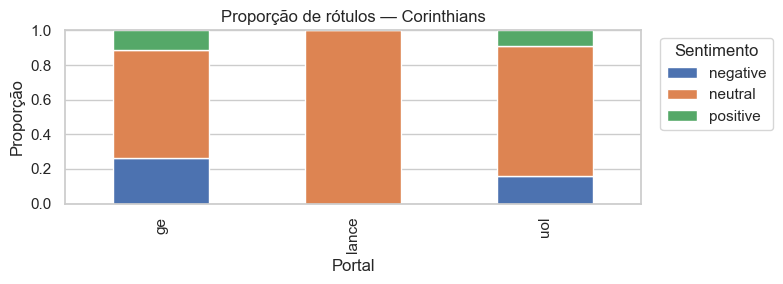

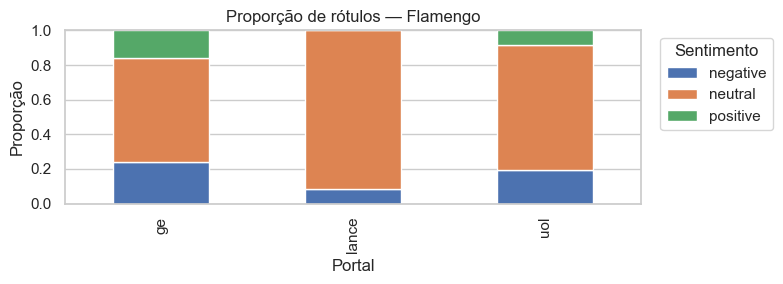

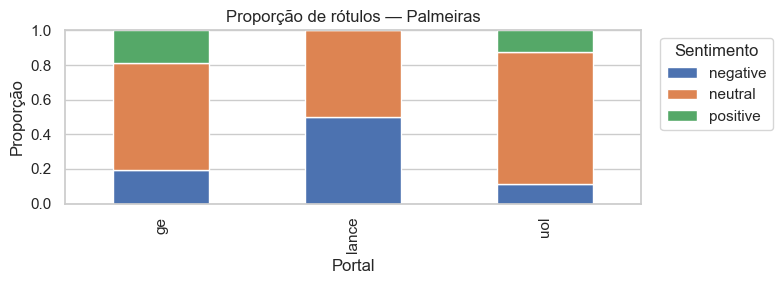

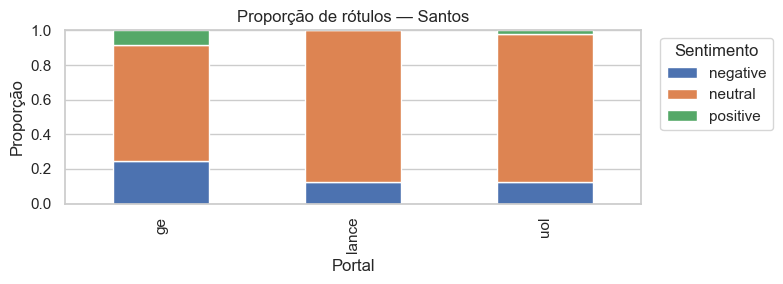

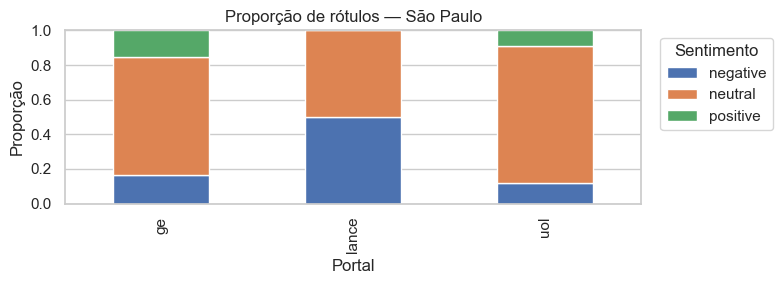

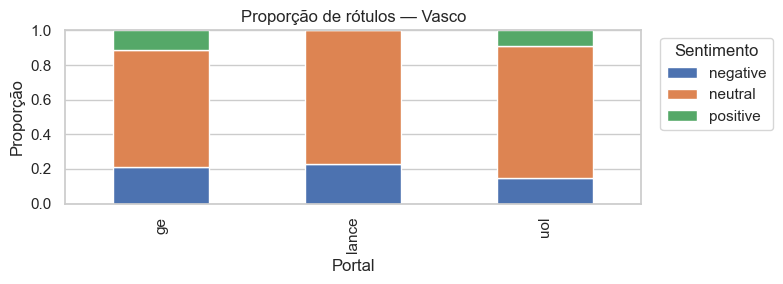

In [19]:
counts = df_dedup.groupby(["clube", "portal", "sent_label"], observed=True).size()
prop = (counts / counts.groupby(["clube", "portal"], observed=True).transform("sum")).rename("prop").reset_index()

for clube in sorted(df_dedup["clube"].unique()):
    sub = prop[prop["clube"] == clube]
    if sub.empty:
        continue
    wide = sub.pivot(index="portal", columns="sent_label", values="prop").fillna(0)
    wide.plot(kind="bar", stacked=True, figsize=(8, 3), title=f"Proporção de rótulos — {clube}")
    plt.ylabel("Proporção")
    plt.xlabel("Portal")
    plt.legend(title="Sentimento", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [20]:
MIN_N_POR_PORTAL = 8

print(
    f"Kruskal-Wallis sobre `sent_indice` por portal (apenas clubes com cada portal com n ≥ {MIN_N_POR_PORTAL}):\n"
)

for clube in sorted(df_dedup["clube"].unique()):
    sub = df_dedup[df_dedup["clube"] == clube]
    grupos = []
    nomes = []
    for portal, g in sub.groupby("portal"):
        if len(g) >= MIN_N_POR_PORTAL:
            grupos.append(g["sent_indice"].values)
            nomes.append(f"{portal} (n={len(g)})")
    if len(grupos) < 2:
        print(f"{clube}: grupos insuficientes para comparar portais ({len(grupos)} portal(is) com n suficiente).")
        continue
    H, p = stats.kruskal(*grupos)
    print(f"{clube}: H={H:.3f}, p-value={p:.4g}  |  " + ", ".join(nomes))
    if p < 0.05:
        print("  → Diferença estatisticamente significativa entre portais (interpretar com cautela: modelo + ruído de títulos).")
    print()

Kruskal-Wallis sobre `sent_indice` por portal (apenas clubes com cada portal com n ≥ 8):

Corinthians: H=1.584, p-value=0.2081  |  ge (n=207), uol (n=76)

Flamengo: H=0.048, p-value=0.9762  |  ge (n=162), lance (n=23), uol (n=94)

Palmeiras: H=5.880, p-value=0.05288  |  ge (n=154), lance (n=8), uol (n=89)

Santos: H=0.702, p-value=0.7042  |  ge (n=163), lance (n=8), uol (n=90)

São Paulo: H=0.044, p-value=0.834  |  ge (n=97), uol (n=100)

Vasco: H=0.974, p-value=0.6145  |  ge (n=134), lance (n=13), uol (n=55)



## Notas de interpretação

- **Modelo:** `cardiffnlp/twitter-xlm-roberta-base-sentiment` (CardiffNLP, base XLM-RoBERTa em tweets).
- **Deduplicação:** a chave é o título normalizado (minúsculas, espaços colapsados). Títulos quase iguais com diferença de pontuação podem contar como distintos.
- **Sentimento:** manchetes de esporte em português podem ser classificadas de forma imperfeita (ironia, nomes próprios, "sinal de alerta" etc.).
- **Barras:** compare `sent_indice` (com confiança) e `sent_polaridade` (sem); a escolha depende se você quer ponderar a incerteza do modelo ou tratar todos os títulos com o mesmo peso no rótulo.
- **Série temporal:** usa `data_rodagem` (dia da coleta no scrape), não a data da notícia no portal; a linha é **média móvel de 7 dias** da **média diária de polaridade** por clube.
- **Kruskal-Wallis:** compara distribuições de `sent_indice` entre portais **dentro do mesmo clube**; exige tamanhos mínimos por grupo.
- **`globoesporte`** nos CSV antigos foi unificado a **`ge`** para comparar com os arquivos `noticias_todos_portais_*`.
